<a href="https://colab.research.google.com/github/leolabs-id/datascience-learning-homework/blob/main/Introduction_to_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [6]:
df_remove_zero = df.copy(deep = True)
df_remove_zero[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']] = df_remove_zero[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']].replace(0,np.nan)

In [7]:
df_remove_zero.isna().sum()

,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [8]:
total = df_remove_zero.isnull().sum().sort_values(ascending = False)
percent = (df_remove_zero.isnull().sum()/df_remove_zero.isnull().count()).sort_values(ascending = False)
missing_data = pd.concat([total,percent], axis=1, keys=['Total','Percent'])
missing_data.head(20)

,Total,Percent
Insulin,374,0.486979
SkinThickness,227,0.295573
BloodPressure,35,0.045573
BMI,11,0.014323
Glucose,5,0.006510
Pregnancies,0,0.000000
DiabetesPedigreeFunction,0,0.000000
Age,0,0.000000
Outcome,0,0.000000


In [9]:
df_remove_zero[df_remove_zero.duplicated()]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome


array([[<Axes: title={'center': 'Pregnancies'}>,
        <Axes: title={'center': 'Glucose'}>,
        <Axes: title={'center': 'BloodPressure'}>],
       [<Axes: title={'center': 'SkinThickness'}>,
        <Axes: title={'center': 'Insulin'}>,
        <Axes: title={'center': 'BMI'}>],
       [<Axes: title={'center': 'DiabetesPedigreeFunction'}>,
        <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Outcome'}>]], dtype=object)

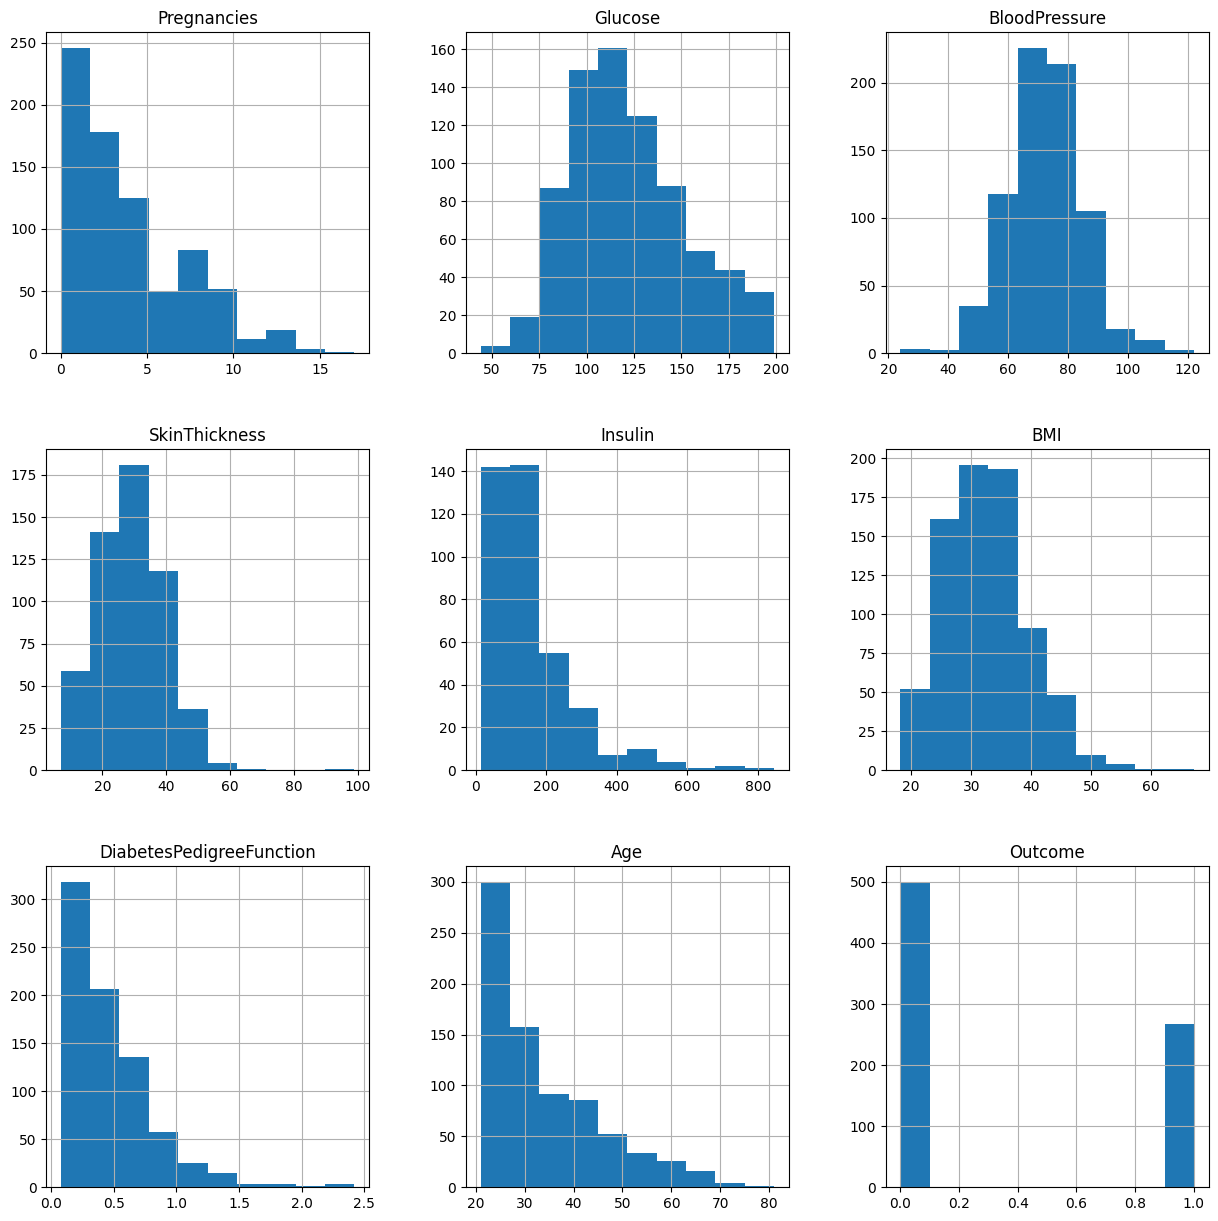

In [10]:
df_remove_zero.hist(figsize=(15,15))

In [11]:
df_remove_zero['Glucose'].fillna(df_remove_zero['Glucose'].median(), inplace = True)
df_remove_zero['BloodPressure'].fillna(df_remove_zero['BloodPressure'].median(), inplace =True)
df_remove_zero['SkinThickness'].fillna(df_remove_zero['SkinThickness'].median(), inplace = True)
df_remove_zero['Insulin'].fillna(df_remove_zero['Insulin'].median(), inplace=True)
df_remove_zero['BMI'].fillna(df_remove_zero['BMI'].median(), inplace=True)

/tmp/ipython-input-3555854815.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_remove_zero['Glucose'].fillna(df_remove_zero['Glucose'].median(), inplace = True)
/tmp/ipython-input-3555854815.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].

array([[<Axes: title={'center': 'Pregnancies'}>,
        <Axes: title={'center': 'Glucose'}>,
        <Axes: title={'center': 'BloodPressure'}>],
       [<Axes: title={'center': 'SkinThickness'}>,
        <Axes: title={'center': 'Insulin'}>,
        <Axes: title={'center': 'BMI'}>],
       [<Axes: title={'center': 'DiabetesPedigreeFunction'}>,
        <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Outcome'}>]], dtype=object)

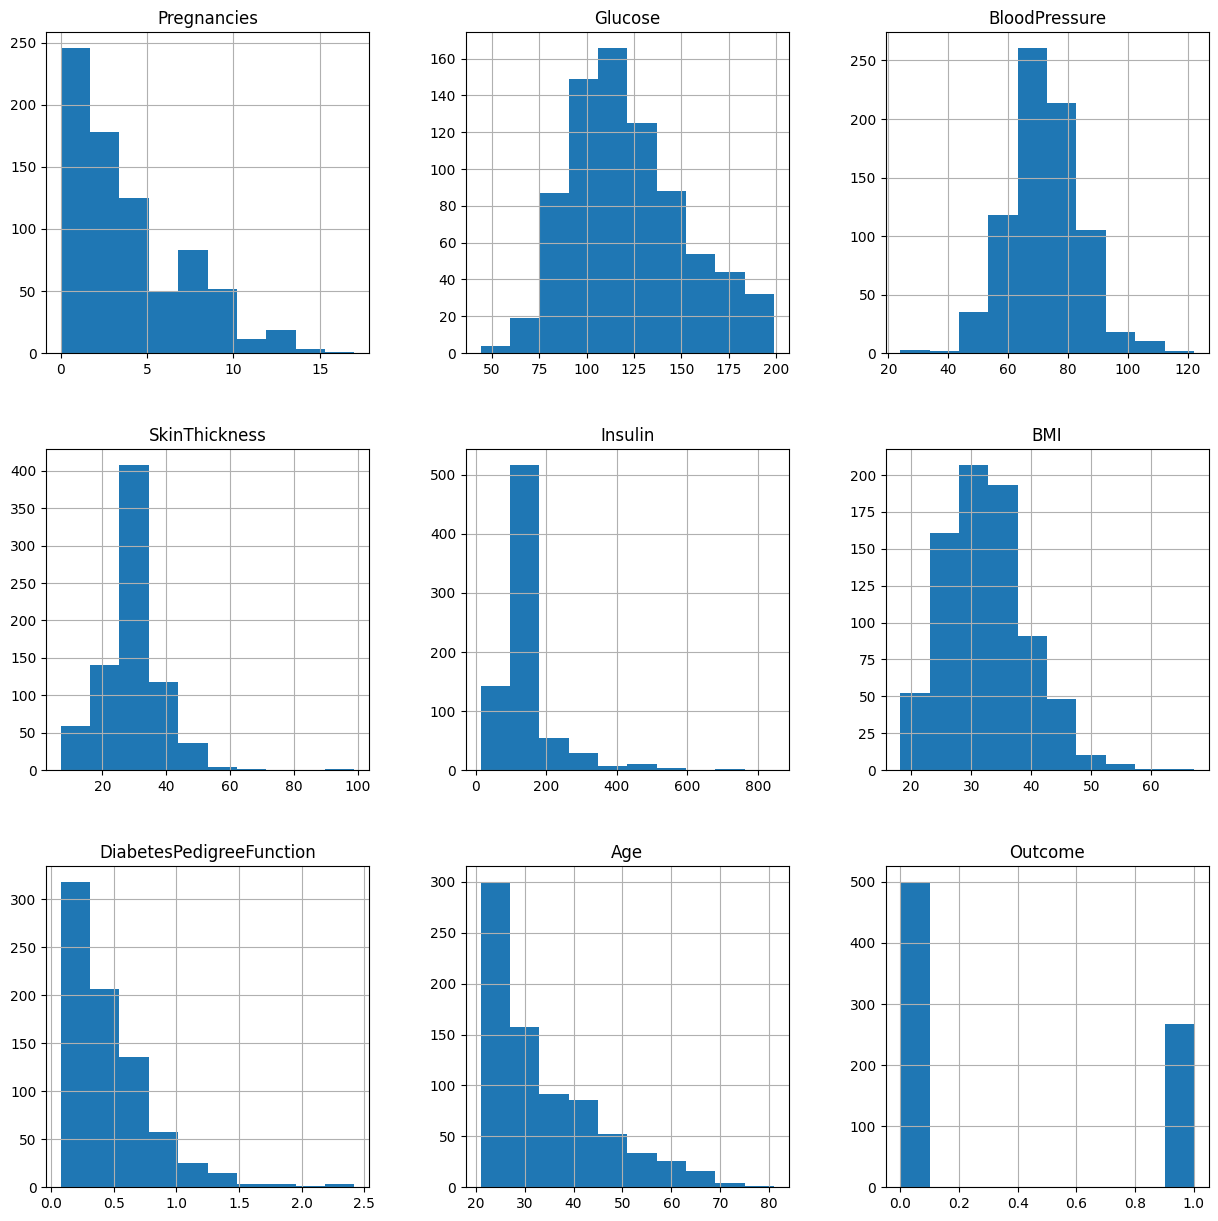

In [12]:
df_remove_zero.hist(figsize=(15,15))

In [13]:
X = df.iloc[:,:-1].values
y = df.iloc[:,-1].values

In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [17]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

In [18]:
X_train_scaled

array([[ 2.80346794,  0.25977903, -3.78077929, ...,  1.03974028,
         0.29608546,  0.96352088],
       [ 0.07832678,  0.25977903,  0.89724451, ...,  0.40945373,
        -0.70087555, -0.86295593],
       [-0.22446668, -1.85825286,  0.67966201, ...,  0.31753694,
        -0.66548048,  1.13747105],
       ...,
       [ 1.89508755, -0.61235174,  0.89724451, ...,  1.78820556,
         1.96850229,  0.44167036],
       [-1.13284707,  0.63354937, -3.78077929, ...,  1.36801453,
        -0.77756486, -0.34110542],
       [-1.13284707,  0.13518892,  1.44120077, ..., -1.24504846,
        -0.6094383 , -1.03690611]])

# Training Model & Evaluation

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

In [20]:
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

[[95 28]
 [24 45]]
              precision    recall  f1-score   support

           0       0.80      0.77      0.79       123
           1       0.62      0.65      0.63        69

    accuracy                           0.73       192
   macro avg       0.71      0.71      0.71       192
weighted avg       0.73      0.73      0.73       192



In [21]:
dt = DecisionTreeClassifier()
dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))


[[87 36]
 [20 49]]
              precision    recall  f1-score   support

           0       0.81      0.71      0.76       123
           1       0.58      0.71      0.64        69

    accuracy                           0.71       192
   macro avg       0.69      0.71      0.70       192
weighted avg       0.73      0.71      0.71       192



In [22]:
rf = RandomForestClassifier()
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

[[99 24]
 [26 43]]
              precision    recall  f1-score   support

           0       0.79      0.80      0.80       123
           1       0.64      0.62      0.63        69

    accuracy                           0.74       192
   macro avg       0.72      0.71      0.72       192
weighted avg       0.74      0.74      0.74       192



# Model Optimization

In [26]:
# Define the models and their respective hyperparameter grids
models = [
    {
        'name': 'Logistic Regression',
        'classifier': LogisticRegression(),
        'params': {
            'C': [0.1, 1, 10]
        }
    },
    {
        'name': 'Decision Tree',
        'classifier': DecisionTreeClassifier(),
        'params':{
            'max_depth': [3, 5, 7]
        }
    },
    {
        'name': 'Random Forest',
        'classifier': RandomForestClassifier(),
        'params':{
            'n_estimators': [100, 200, 300],
            'max_depth': [3, 5, 7]
        }
    }

]

In [27]:
from sklearn.model_selection import cross_val_score, GridSearchCV

# Perform cross-validation and hyperparameter tuning for each model
for model in models:
  print(f"Model: {model['name']}")

  # Crate the classifier with default hyperparameters
  classifier = model['classifier']

  # Perform hyperparameter tuning using GridSearchCV
  grid_search = GridSearchCV(classifier, model['params'], cv=5, scoring='accuracy')
  grid_search.fit(X_train_scaled, y_train)

  # Set the best parameters to the classifier
  best_params = grid_search.best_params_
  print(f"Best hyiperparameters: {best_params}")
  classifier.set_params(**best_params)

  # Perform cross-valitation after hyperparameter tuning
  scores = cross_val_score(classifier, X_train_scaled, y_train, cv=5, scoring='accuracy')
  print(f"Accuracy after hyperparameter tuning: {np.mean(scores)}")
  print('-'*50)




Model: Logistic Regression
Best hyiperparameters: {'C': 1}
Accuracy after hyperparameter tuning: 0.7759820089955023
--------------------------------------------------
Model: Decision Tree
Best hyiperparameters: {'max_depth': 3}
Accuracy after hyperparameter tuning: 0.7413043478260869
--------------------------------------------------
Model: Random Forest
Best hyiperparameters: {'max_depth': 5, 'n_estimators': 300}
Accuracy after hyperparameter tuning: 0.7760419790104948
--------------------------------------------------
